# Exploratory Data Analysis (EDA) on Online Retail

## 1. Giới thiệu
Bộ dữ liệu Online Retail ghi nhận toàn bộ các giao dịch bán hàng từ một công ty bán lẻ trực tuyến có trụ sở tại Vương quốc Anh trong giai đoạn 01/12/2010 đến 09/12/2011. Công ty này chuyên kinh doanh các sản phẩm quà tặng, đồ trang trí nhỏ lẻ, thường được các khách hàng doanh nghiệp và người mua lẻ đặt hàng với số lượng lớn.

Mục tiêu chính của bài toán này là nắm bắt nhu cầu của khách hàng để đưa ra định hướng kinh doanh, phát hiện thị trường tiềm năng ở các quốc gia khác.

Chúng ta cần phân tích hành vi mua sắm của khác hàng, xác định sản phẩm bán chạy nhất, đánh giá doanh thu theo thời gian và theo quốc gia.

## 2. Chuẩn bị vấn đề

### 2.1 Khởi tạo thư viện cần thiết
- `pandas`: xử lý dữ liệu dạng bảng (DataFrame)
- `numpy`: hỗ trợ tính toán số học
- `matplotlib.pyplot`: vẽ biểu đồ cơ bản
- `seaborn`: trực quan hóa nâng cao, hỗ trợ biểu đồ đẹp và dễ đọc

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

### 2.2 Nạp dữ liệu

In [71]:
df = pd.read_excel('Online_Retail.xlsx')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## 3. Phân tích dữ liệu
### 3.1 Thông tin tổng quan về dữ liệu
- `InvoiceNo`: mã hóa đơn
- `StockCode`: mã sản phẩm
- `Description`: mô tả sản phảm
- `Quantity`: số lượng mua (có thể âm nếu là trả hàng)
- `InvoiceDate`: thời điểm lập hóa đơn
- `UnitPrice`: giá đơn vị
- `CustomerID`: mã khách hàng
` `Country`: quốc gia của khách hàng

### 3.2 Làm sạch dữ liệu

#### 3.2.1 Kiểm tra kiểu dữ liệu
+ Đôi khi 1 số kiểu dữ liệu số nhưng được lưu ở dạng chuỗi , nên nếu gặp trường hợp đó ta cần chuyển đổi chuỗi thành dữ liệu số nguyên để có thể vẽ dữ liệu qua biểu đồ.

In [86]:
df.dtypes

Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

**Nhận xét:** 
+ Ở đây, trong trường hợp này, dữ liệu `Quantity` đang ở dạng số nguyên và `UnitPrice` đang ở dạng số thực nên không có vấn đề gì.

**Kiểm tra các cột tồn tại trong dữ liệu**

In [87]:
df.columns

Index(['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID',
       'Country'],
      dtype='object')

#### 3.2.2. Xóa đi các cột không liên quan
+ Đôi khi có nhiều cột chúng ta không sử dụng chúng bao giờ, trong trường hợp đó lựa chọn xóa đi các cột như vậy sẽ là giải pháp duy nhất tốt hơn là việc để lại làm rối dữ liệu.

In [88]:
df.drop(['InvoiceNo', 'StockCode'], axis=1, inplace=True, errors='ignore')

df.head(5)

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**Nhận xét :**
+ Trong trường hợp này, các cột như `InvoiceNo` và `StockCode` sẽ không được sử dụng để trình bày nên ta xóa chúng ra khỏi DataFrame.<br>
&rarr; DataFrame của ta sẽ từ 8 cột dữ liệu thành 6 cột.

#### 3.2.3. Xóa các hàng có trùng lặp.
Các hàng thường sẽ có một số dữ liệu trùng lặp, điều này có ảnh hưởng đến tính toàn vẹn của dữ liệu, vì vậy ở đây chúng ta sẽ xóa đi các giá trị/hàng trùng lặp khỏi tập dữ liệu.

+ *Kiểm tra tổng số hàng dữ liệu:*

In [89]:
df.shape

(524231, 6)

&nbsp;&nbsp;&nbsp;&nbsp;&rarr; Ở đây, tập dữ liệu của ta có tổng cộng tất cả là 541909 hàng và 6 cột.

+ *Kiểm tra các hàng trùng lặp*

In [90]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 6)


&nbsp;&nbsp;&nbsp;&nbsp;&rarr; Chúng ta có 6007 hàng có dữ liệu bị trùng với những hàng khác.

+ *Đếm số lượng dữ liệu trên mỗi cột*

In [91]:
df.count()

Description    524231
Quantity       524231
InvoiceDate    524231
UnitPrice      524231
CustomerID     392617
Country        524231
dtype: int64

+ *Xóa đi những hàng có dữ liệu bị trùng lặp:*

In [92]:
df = df.drop_duplicates()
df.head(5)

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


+ *Đếm lại số hàng hiện tại sau khi đã xóa đi những dữ liệu bị trùng*

In [93]:
df.count()

Description    524231
Quantity       524231
InvoiceDate    524231
UnitPrice      524231
CustomerID     392617
Country        524231
dtype: int64

&nbsp;&nbsp;&nbsp;&nbsp;&rarr; Các giá trị trên vẫn chưa khớp nhau nên tiếp theo chúng ta sẽ tiếp tục kiểm tra các bất thường khác.

#### 3.2.4. Xóa các giá trị thiếu hoặc NaN
Vì cột **Description** chứa tên hoặc chi tiết sản phẩm, việc có các giá trị này là rất quan trọng vì chúng có khả năng ảnh hưởng đến báo cáo của dữ liệu. Nên tất cả các hàng có giá trị bị thiếu hoặc NaN trong cột **Description** sẽ bị loại bỏ.

+ *Kiểm tra và đếm số giá trị null trong DataFrame:*

In [94]:
print(df.isnull().sum())

Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     131614
Country             0
dtype: int64


&nbsp;&nbsp;&nbsp;&nbsp;&rarr; Hiện tại có 1370 dòng dữ liệu ở cột **Description** bị thiếu.

+ *Tiến hành xóa các dòng có dữ liệu bị thiếu hoặc null ở cột **Description*** :

In [95]:
df = df.dropna(subset=['Description']) # Xóa các hàng có giá trị NaN trong cột 'Description'
df.count()

Description    524231
Quantity       524231
InvoiceDate    524231
UnitPrice      524231
CustomerID     392617
Country        524231
dtype: int64

**Nhận xét :**
+ Sau khi thực hiện xóa các dữ liệu thiếu ở **Description** thì các cột đã có cùng số lượng dữ liệu ngoại trừ **CustomerID**.<br>
+ Ta nhận thấy số lượng thiếu của cột **CustomerID** quá lớn, nếu xóa tất cả các hàng này sẽ làm giảm đáng kể lượng dữ liệu khả dụng.<br>
&rarr; Vì vậy, ta sẽ giữ lại các hàng bị ảnh hưởng này vì các cột khác đều đủ dữ liệu.

### 3.3. Thống kê cơ bản
- Count, Mean, Standard Deviation, Minimum Value
- 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [41]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


**Nhận xét :**<br>
&nbsp;&nbsp;&nbsp;&nbsp; Ta nhận thấy ở cả cột **Quantity** và **UnitPrice** đều có các giá trị âm (được thể hiện bởi min). Vì thế ta cần kiểm tra và loại bỏ các hàng có giá trị âm vì chúng có thể ảnh hưởng đến tính toàn vẹn dữ liệu của chúng ta.

+ *Kiểm tra các hàng có dữ liệu là giá trị âm :*

In [82]:
numeric_df = df.select_dtypes(include=[np.number])

negative_counts = (numeric_df < 0).sum()
print("Các cột có giá trị âm và số lượng của chúng:")
print(negative_counts)

Các cột có giá trị âm và số lượng của chúng:
Quantity      10544
UnitPrice         2
CustomerID        0
dtype: int64


+ *Loại bỏ các hàng có giá trị nhỏ hơn hoặc bằng 0 :*

In [83]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print(df.count())

Description    524231
Quantity       524231
InvoiceDate    524231
UnitPrice      524231
CustomerID     392617
Country        524231
dtype: int64


+ *Kiểm tra lại xem còn bỏ xót giá trị âm nào không :*


In [84]:
numeric_df = df.select_dtypes(include=[np.number])

negative_counts = (numeric_df < 0).sum()
print("Các cột có giá trị âm và số lượng của chúng:")
print(negative_counts)

Các cột có giá trị âm và số lượng của chúng:
Quantity      0
UnitPrice     0
CustomerID    0
dtype: int64


## 4. Trực quan hóa dữ liệu

### 4.1. Phân tích doanh thu theo quốc gia

#### 4.1.1. Tạo thêm 1 cột dữ liệu mới
+ Tạo thêm 1 cột dữ liệu `Sale` từ dữ liệu có sẵn: `Sale` = `Quantity` * `UnitPrice`.

In [97]:
df['Sale'] = df['Quantity'] * df['UnitPrice']

print("Tập dữ liệu sau khi thêm cột 'Sale':")
df.head()

Tập dữ liệu sau khi thêm cột 'Sale':


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sale
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


+ Đếm và hiển thị số lượng đặt hàng theo quốc gia

In [98]:
df.Country.value_counts()

Country
United Kingdom          479341
Germany                   9024
France                    8392
EIRE                      7879
Spain                     2479
Netherlands               2359
Belgium                   2031
Switzerland               1958
Portugal                  1492
Australia                 1181
Norway                    1071
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     602
Sweden                     450
Unspecified                442
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     291
Hong Kong                  280
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57


#### 4.1.2. Trực quan hóa những quốc gia có giao dịch đặt hàng nhiều nhất

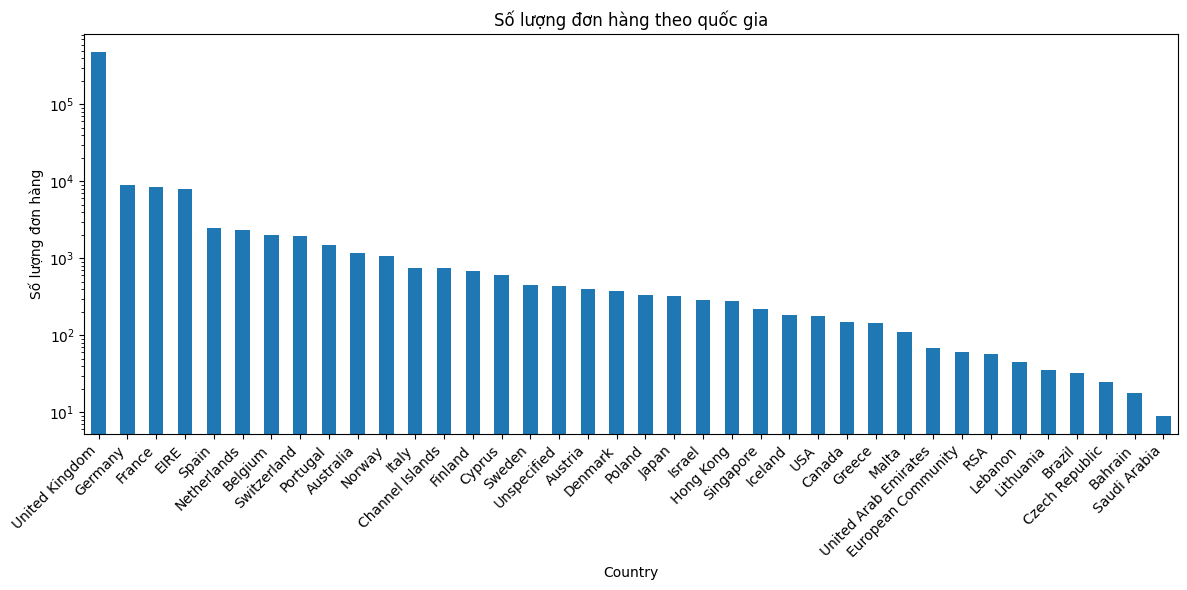

In [99]:
country_counts = df['Country'].value_counts().nlargest(40)

plt.figure(figsize=(12, 6))
country_counts.plot(kind='bar', logy=True) 
plt.title("Số lượng đơn hàng theo quốc gia")
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()  
plt.show()

#### 4.1.3. Tổng số giao dịch và doanh số

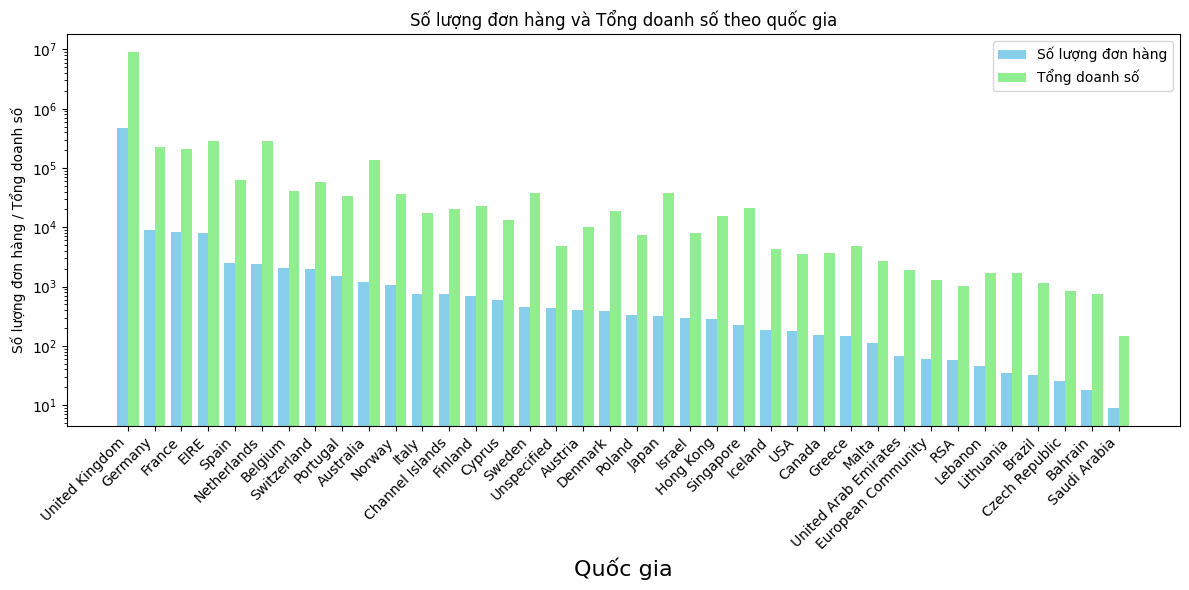

In [104]:
country_counts = df['Country'].value_counts().nlargest(40)

sales_per_country = df.groupby('Country')['Sale'].sum().loc[country_counts.index]

# Kích thước hình và thiết lập biểu đồ
plt.figure(figsize=(12, 6))

# Chiều rộng của các thanh
bar_wight = 0.4

x = np.arange(len(country_counts))

plt.bar(x - bar_wight/2, country_counts, width=bar_wight, color = 'skyblue', label='Số lượng đơn hàng', log=True)
plt.bar(x + bar_wight/2, sales_per_country, width=bar_wight, color = 'lightgreen', label='Tổng doanh số', log=True)

plt.xticks(x, country_counts.index, rotation=45, ha='right')
plt.xlabel('Quốc gia', fontsize=16)
plt.ylabel('Số lượng đơn hàng / Tổng doanh số')
plt.title('Số lượng đơn hàng và Tổng doanh số theo quốc gia')
plt.legend()

plt.tight_layout()
plt.show()

**Nhận xét :**
+ *United Kingdom* là thị trường lớn nhất với 479.341 giao dịch đặt hàng, cao hơn đáng kể so với tất cả các quốc gia còn lại.<br>
+ Các thị trường quốc tế trọng điểm tiếp theo như: *Đức* (9.024), *Pháp* (8.392) và *EIRE* (7.879). Các quốc gia này đại diện cho những thị trường quốc tế quan trọng đối với hoạt động kinh doanh.
+ Các quốc gia như *Tây Ban Nha* (2.479), *Hà Lan* (2.359) và *Bỉ* (2.031) có khối lượng đơn hàng vừa phải, cho thấy những lĩnh vực tiềm năng để tăng trưởng và các nỗ lực tiếp thị được nhắm mục tiêu.

### 4.2. Khám phá các sản phẩm bán chạy nhất

#### 4.2.1. Các sản phẩm bán chạy nhất dựa trên số lượng lượt bán

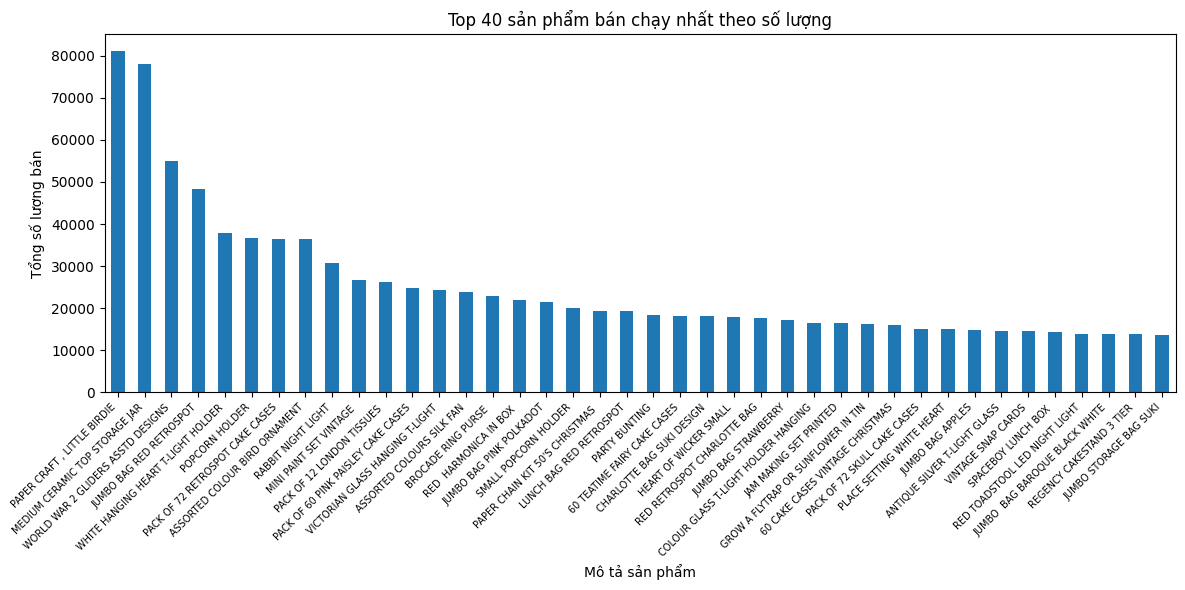

Các sản phẩm bán chạy nhất dựa trên số lượng lượt bán :


Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS      54951
JUMBO BAG RED RETROSPOT                48349
WHITE HANGING HEART T-LIGHT HOLDER     37869
POPCORN HOLDER                         36745
PACK OF 72 RETROSPOT CAKE CASES        36396
ASSORTED COLOUR BIRD ORNAMENT          36362
RABBIT NIGHT LIGHT                     30737
MINI PAINT SET VINTAGE                 26633
PACK OF 12 LONDON TISSUES              26119
PACK OF 60 PINK PAISLEY CAKE CASES     24814
VICTORIAN GLASS HANGING T-LIGHT        24275
ASSORTED COLOURS SILK FAN              23826
BROCADE RING PURSE                     23020
RED  HARMONICA IN BOX                  21903
JUMBO BAG PINK POLKADOT                21413
SMALL POPCORN HOLDER                   20142
PAPER CHAIN KIT 50'S CHRISTMAS         19329
LUNCH BAG RED RETROSPOT                19227
PARTY BUNTING                          18282
60 TEATIME FAIRY CAKE CASES            1818

In [109]:
quantity_per_description = df.groupby('Description')['Quantity'].sum().nlargest(40)

plt.figure(figsize=(12, 6))
quantity_per_description.plot(kind='bar')
plt.title('Top 40 sản phẩm bán chạy nhất theo số lượng')
plt.xlabel('Mô tả sản phẩm')
plt.ylabel('Tổng số lượng bán')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

print("Các sản phẩm bán chạy nhất dựa trên số lượng lượt bán :")
quantity_per_description

***Các sản phẩm bán chạy nhất dựa trên số lượng đặt hàng là :***
+ *PAPER CRAFT* , *LITTLE BIRDIE* : 80995 chiếc<br>
+ *MEDIUM CERAMIC TOP STORAGE JAR* : 78033 chiếc <br>
+ *WORLD WAR 2 GLIDERS ASSTD DESIGNS* : 54,951 chiếc <br>
+ *JUMBO BAG RED RETROSPOT* : 48,349 chiếc<br>
+ *WHITE HANGING HEART T-LIGHT HOLDER* : 37,869 chiếc<br>
&rarr;Những mặt hàng này cho thấy doanh số bán hàng đáng kể, nhu cầu cao. Các sản phẩm như đồ thủ công bằng giấy và hũ đựng đồ cho thấy xu hướng ưa chuộng các mặt hàng trang trí và thiết thực.

#### 4.2.2. Số lượng sản phẩm cho từng khách hàng

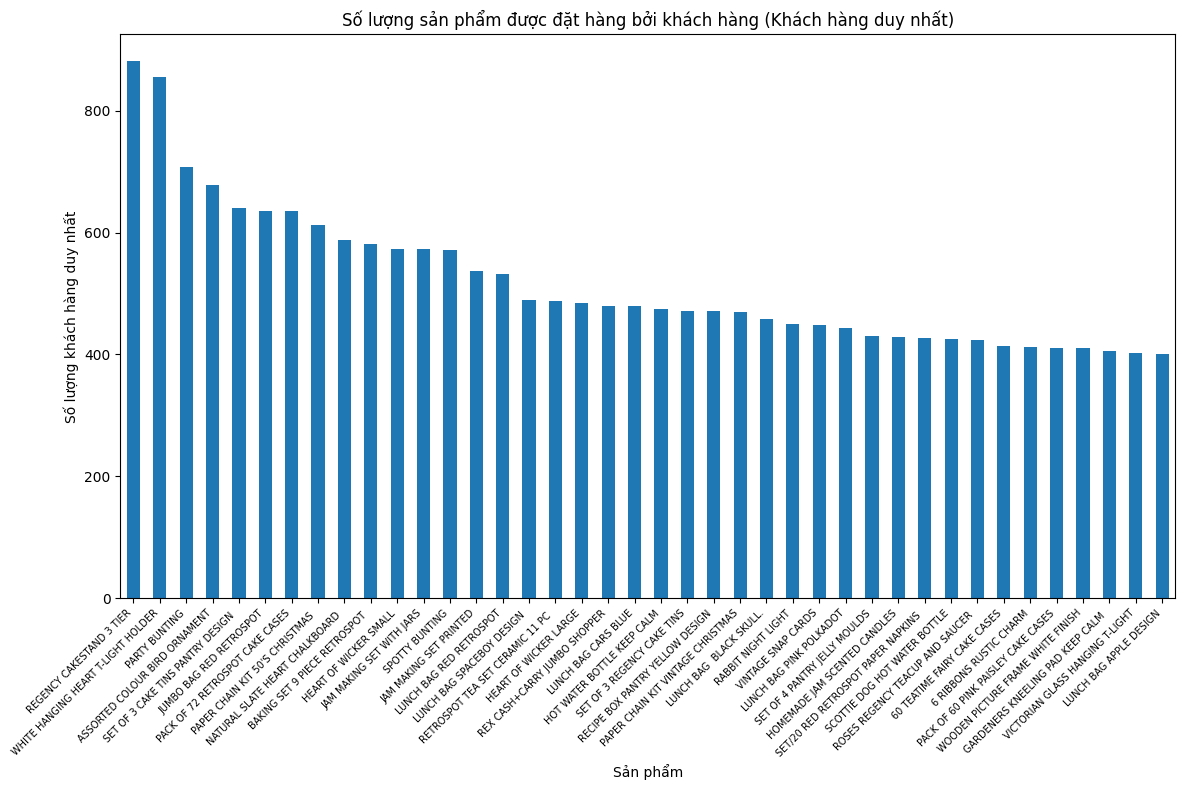

In [111]:
quantity_per_description_customer = df.groupby(['Description', 'CustomerID'])['Quantity'].sum().reset_index()

quantity_per_description_unique_customers = quantity_per_description_customer.groupby('Description').size().nlargest(40)

plt.figure(figsize=(12, 8))
quantity_per_description_unique_customers.plot(kind='bar')
plt.title("Số lượng sản phẩm được đặt hàng bởi khách hàng (Khách hàng duy nhất)")
plt.ylabel('Số lượng khách hàng duy nhất')
plt.xlabel('Sản phẩm')
plt.xticks(rotation=45, ha='right', fontsize=7)  
plt.tight_layout() 
plt.show()

In [112]:
print(quantity_per_description_unique_customers)

Description
REGENCY CAKESTAND 3 TIER               881
WHITE HANGING HEART T-LIGHT HOLDER     856
PARTY BUNTING                          708
ASSORTED COLOUR BIRD ORNAMENT          678
SET OF 3 CAKE TINS PANTRY DESIGN       640
JUMBO BAG RED RETROSPOT                635
PACK OF 72 RETROSPOT CAKE CASES        635
PAPER CHAIN KIT 50'S CHRISTMAS         613
NATURAL SLATE HEART CHALKBOARD         587
BAKING SET 9 PIECE RETROSPOT           581
HEART OF WICKER SMALL                  573
JAM MAKING SET WITH JARS               573
SPOTTY BUNTING                         571
JAM MAKING SET PRINTED                 537
LUNCH BAG RED RETROSPOT                532
LUNCH BAG SPACEBOY DESIGN              490
RETROSPOT TEA SET CERAMIC 11 PC        488
HEART OF WICKER LARGE                  485
REX CASH+CARRY JUMBO SHOPPER           480
LUNCH BAG CARS BLUE                    479
HOT WATER BOTTLE KEEP CALM             474
SET OF 3 REGENCY CAKE TINS             472
RECIPE BOX PANTRY YELLOW DESIGN        471

Quan sát biểu đồ ta nhận thấy:
+ *REGENCY CAKESTAND 3 TIER*: 881 người<br>
+ *WHITE HANGING HEART T-LIGHT HOLDER*: 856<br>
+ *PARTY BUNTING*: 708<br>
+ *ASSORTED COLOUR BIRD ORNAMENT*: 678 người<br>
+ *SET OF 3 CAKE TINS PANTRY DESIGN*: 640 người<br>
Những sản phẩm này không chỉ phổ biến về tổng số lượng bán ra mà còn được nhiều khách hàng cá nhân mua. Điều này cho thấy những mặt hàng này có sức hấp dẫn rộng rãi đối với nhiều đối tượng khách hàng.

C:\Users\DANG KHOA\AppData\Local\Temp\ipykernel_36876\3547964431.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quantity_per_product.values, y=quantity_per_product.index, palette='viridis')


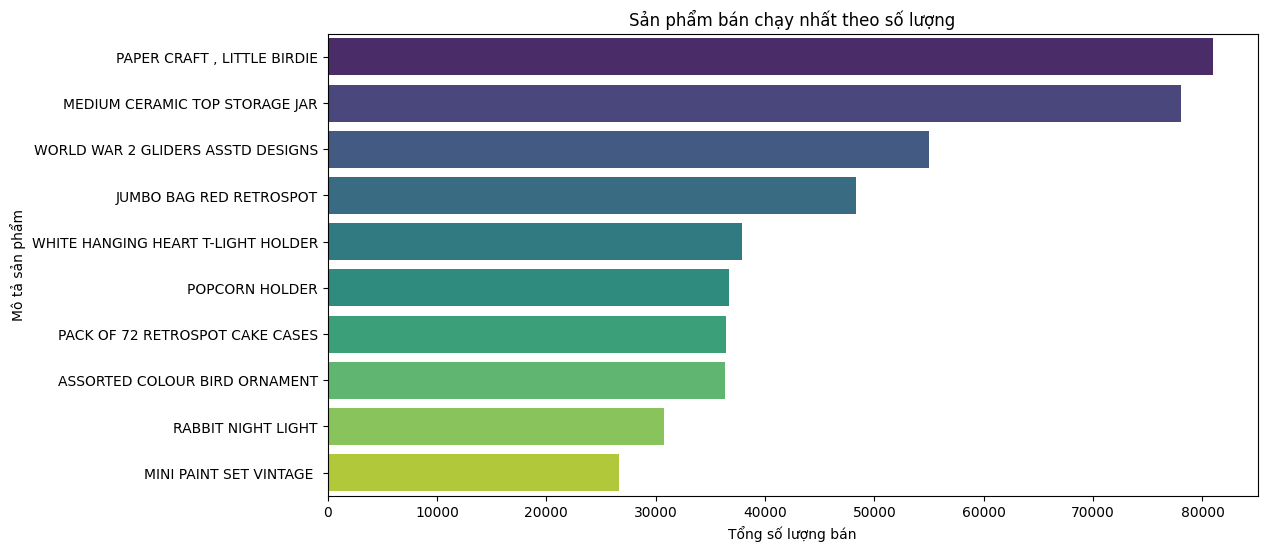

C:\Users\DANG KHOA\AppData\Local\Temp\ipykernel_36876\3547964431.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quantity_per_country.values, y=quantity_per_country.index, palette='viridis')


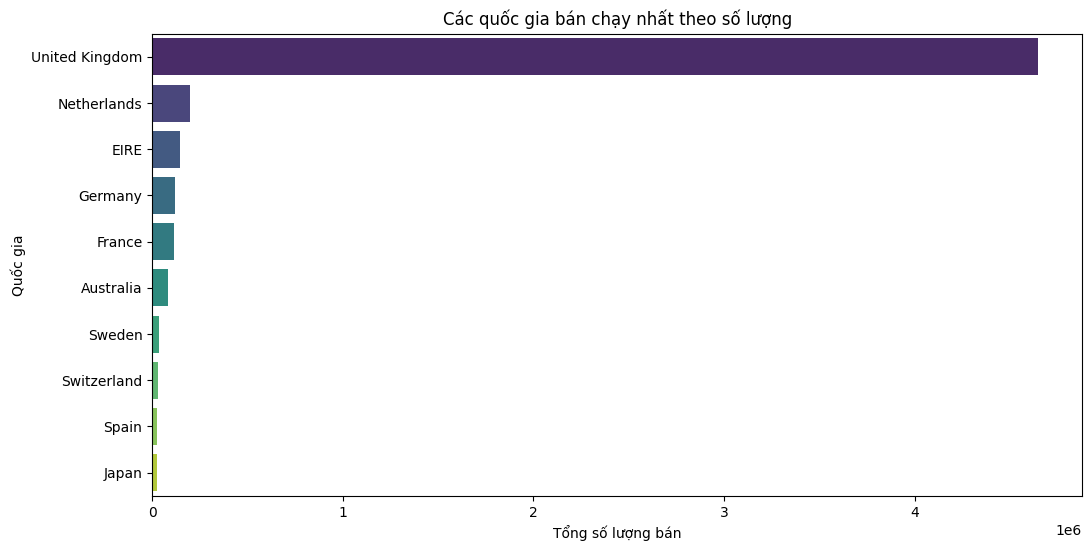

In [114]:
quantity_per_product = df.groupby('Description')['Quantity'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=quantity_per_product.values, y=quantity_per_product.index, palette='viridis')
plt.title('Sản phẩm bán chạy nhất theo số lượng')
plt.xlabel('Tổng số lượng bán')
plt.ylabel('Mô tả sản phẩm')
plt.show()

quantity_per_country = df.groupby('Country')['Quantity'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=quantity_per_country.values, y=quantity_per_country.index, palette='viridis')
plt.title('Các quốc gia bán chạy nhất theo số lượng')
plt.xlabel('Tổng số lượng bán')
plt.ylabel('Quốc gia')
plt.show()

### 4.3. Phân tích xu hướng bán hàng theo thời gian

+ ***Xác định tháng và ngày trong tuần có doanh số cao nhất***

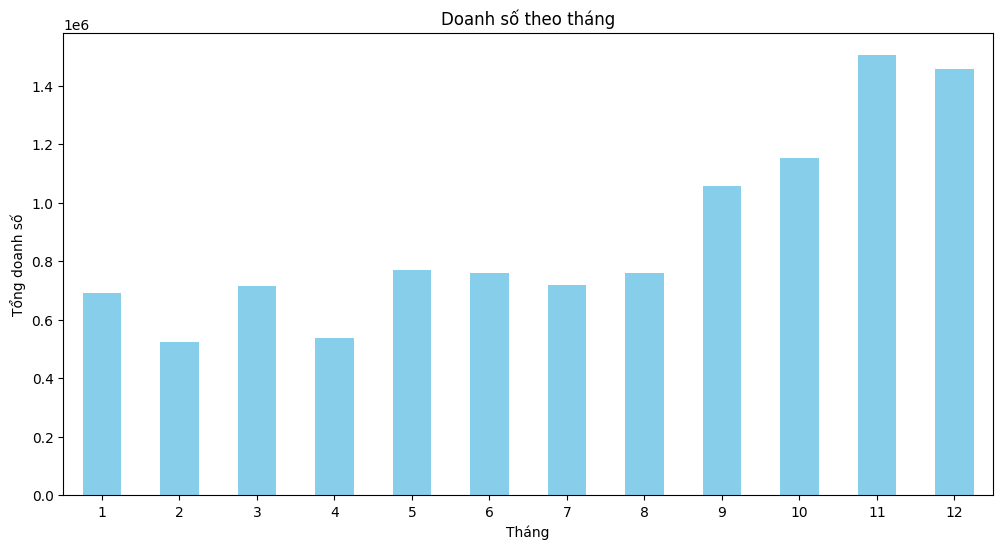

C:\Users\DANG KHOA\AppData\Local\Temp\ipykernel_36876\3119351410.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dayofweek_sales.index, y=dayofweek_sales.values, palette='viridis')


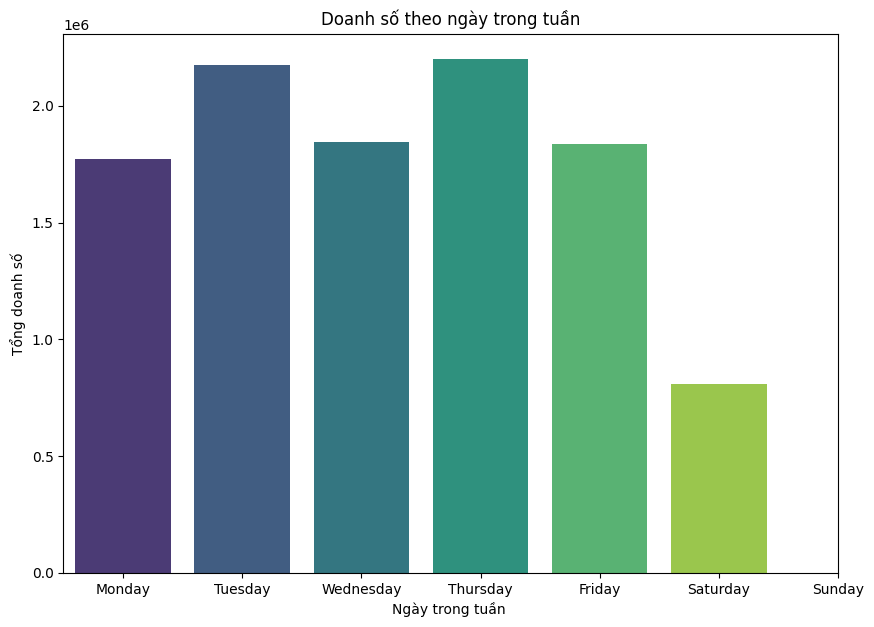

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

monthly_sales = df.groupby('Month')['Sale'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='bar', color='skyblue')
plt.title('Doanh số theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Tổng doanh số')
plt.xticks(rotation=0)
plt.show()

dayofweek_sales = df.groupby('DayOfWeek')['Sale'].sum()

plt.figure(figsize=(10, 7))
sns.barplot(x=dayofweek_sales.index, y=dayofweek_sales.values, palette='viridis')
plt.title('Doanh số theo ngày trong tuần')
plt.xlabel('Ngày trong tuần ')
plt.ylabel('Tổng doanh số')
plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

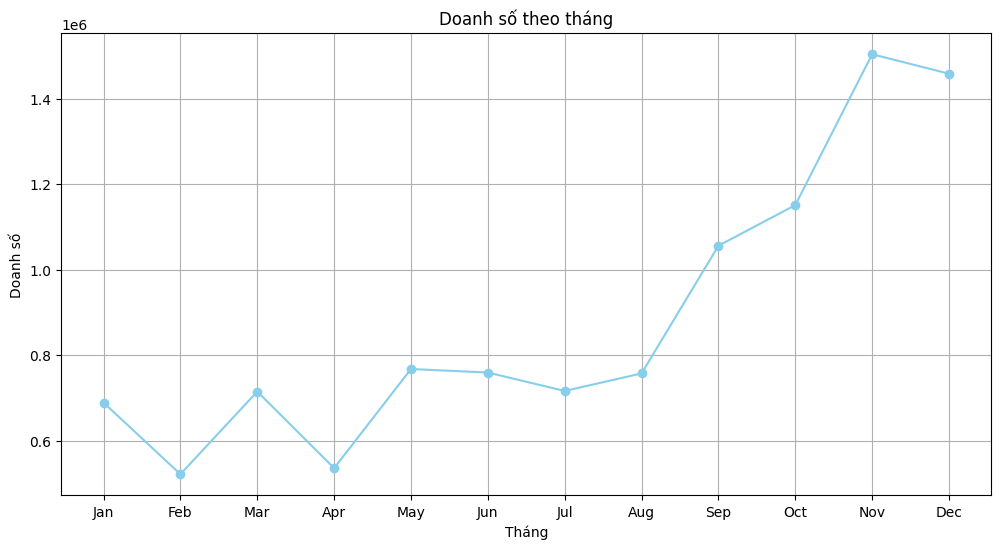

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %I:%M:%S %p')

df['Month'] = df['InvoiceDate'].dt.month
# df['Year'] = df['InvoiceDate'].dt.year

monthly_sales = df.groupby(['Month'])['Sale'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='skyblue')
plt.title('Doanh số theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Doanh số')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

## 5. Xác định ngoại lệ và bất thường

<Axes: xlabel='UnitPrice'>

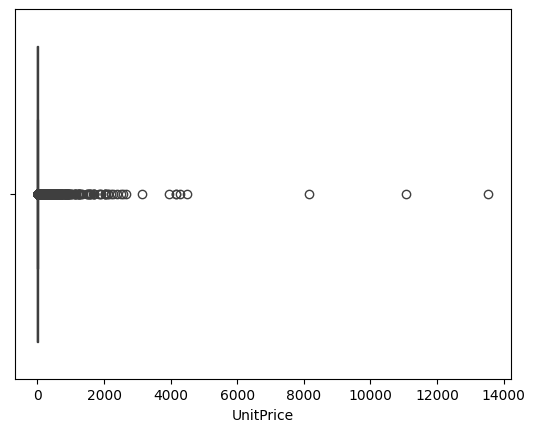

In [123]:
sns.boxplot(x=df['UnitPrice'])

<Axes: xlabel='Quantity'>

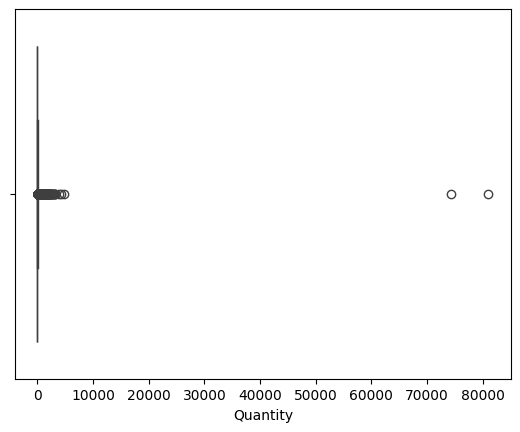

In [124]:
sns.boxplot(x=df['Quantity'])

<Axes: xlabel='Sale'>

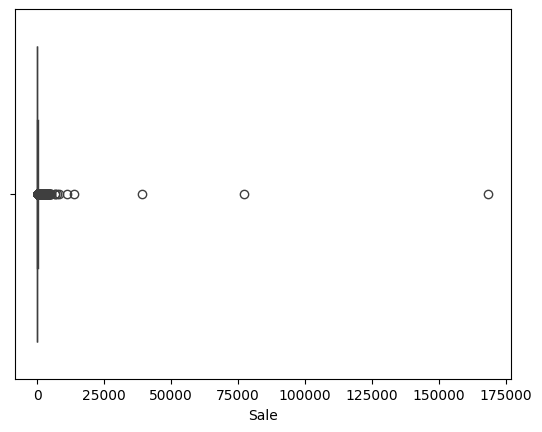

In [126]:
sns.boxplot(x=df['Sale'])

In [129]:
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1
print(IQR)


Quantity        10.00
UnitPrice        2.88
CustomerID    2836.00
Sale            13.80
Month            6.00
DayOfWeek        3.00
dtype: float64
